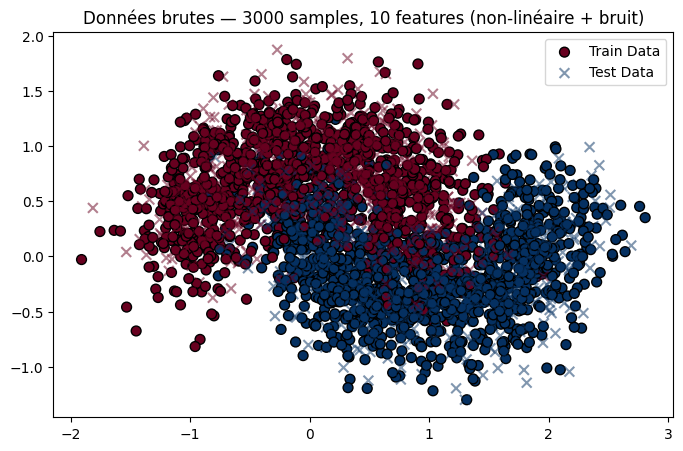

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay

# ── Données : 3000 samples, 50 features (2 moons + 8 bruit) ──
X_moons, y = make_moons(n_samples=3000, noise=0.30, random_state=42)
X_noise = np.random.rand(3000, 8)
X = np.hstack([X_moons, X_noise])  # 10 features réalistes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ── Visualisation des données brutes (2 premières features) ──
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', s=50, label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, s=50, label='Test Data')
plt.title('Données brutes — 3000 samples, 10 features (non-linéaire + bruit)')
plt.legend()
plt.show()


--- L2 (C=0.1) ---
Score Train : 0.8800 | Score Test : 0.8822
Coefficients nuls : 1 / 10
------------------------------
--- L1 (C=0.5) ---
Score Train : 0.9019 | Score Test : 0.9078
Coefficients nuls : 2 / 10
------------------------------
--- Sans pénalité ---
Score Train : 0.9024 | Score Test : 0.9089
Coefficients nuls : 1 / 10
------------------------------


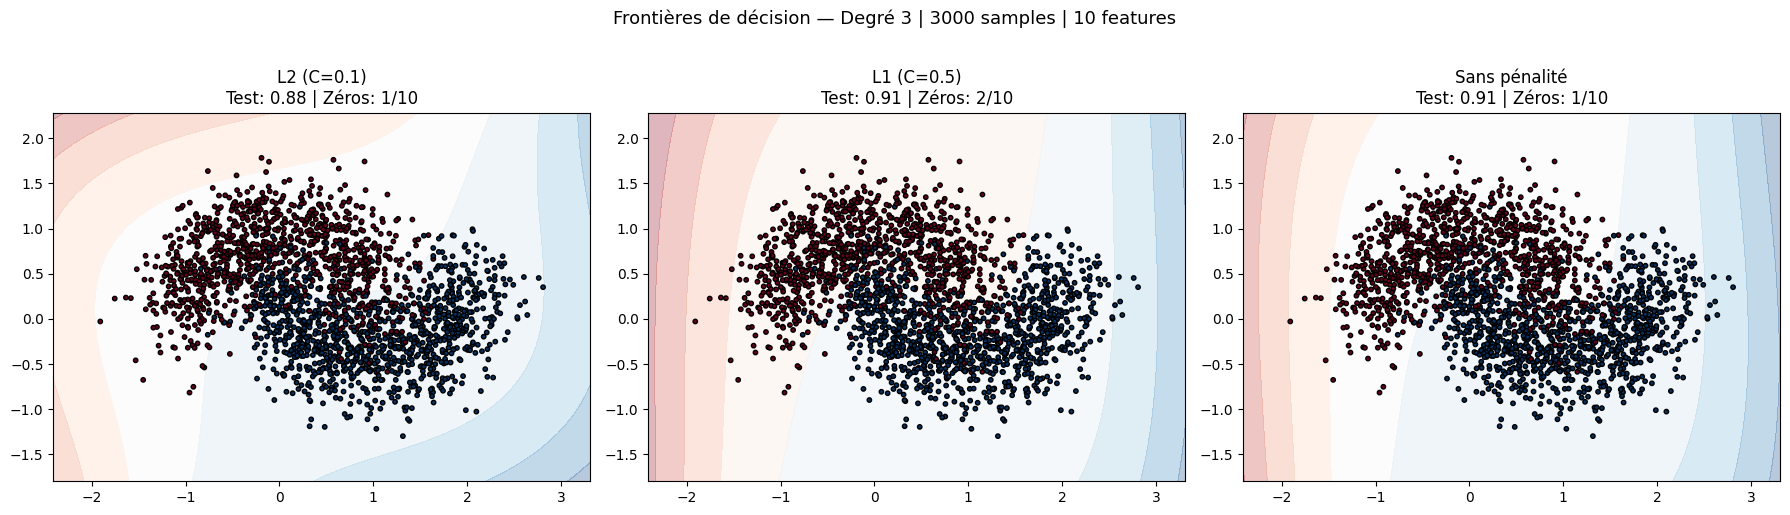

In [14]:
# ── Frontières de décision — L2 (C=0.1) vs L1 (C=0.5) vs Aucune ──
# Visualisation sur les 2 premières features (moons) pour lisibilité
X2_train, X2_test = X_train[:, :2], X_test[:, :2]

modeles_viz = {
    'L2 (C=0.1)': make_pipeline(
        PolynomialFeatures(degree=3), StandardScaler(),
        LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', max_iter=2000)
    ),
    'L1 (C=0.5)': make_pipeline(
        PolynomialFeatures(degree=3), StandardScaler(),
        LogisticRegression(penalty='l1', C=0.5, solver='liblinear', max_iter=2000)
    ),
    'Sans pénalité': make_pipeline(
        PolynomialFeatures(degree=3), StandardScaler(),
        LogisticRegression(penalty=None, max_iter=2000)
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nom, modele) in zip(axes, modeles_viz.items()):
    modele.fit(X2_train, y_train)
    coefs = modele.named_steps['logisticregression'].coef_
    n_zeros = (coefs == 0).sum()
    total_params = coefs.size
    score_train = modele.score(X2_train, y_train)
    score_test  = modele.score(X2_test,  y_test)

    print(f'--- {nom} ---')
    print(f'Score Train : {score_train:.4f} | Score Test : {score_test:.4f}')
    print(f'Coefficients nuls : {n_zeros} / {total_params}')
    print('-' * 30)

    DecisionBoundaryDisplay.from_estimator(modele, X2_train, cmap='RdBu', alpha=0.3, ax=ax, eps=0.5)
    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', s=10)
    ax.set_title(f'{nom}\nTest: {score_test:.2f} | Zéros: {n_zeros}/{total_params}')

plt.suptitle('Frontières de décision — Degré 3 | 3000 samples | 10 features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Entraînement en cours...
D2 L2        | Train: 0.851 | Test: 0.838 | Gap: 0.014
D2 L1        | Train: 0.849 | Test: 0.842 | Gap: 0.006
D2 Aucune    | Train: 0.847 | Test: 0.837 | Gap: 0.010
D3 L2        | Train: 0.890 | Test: 0.872 | Gap: 0.017
D3 L1        | Train: 0.910 | Test: 0.898 | Gap: 0.012
D3 Aucune    | Train: 0.940 | Test: 0.866 | Gap: 0.075 ⚠ surapprentissage


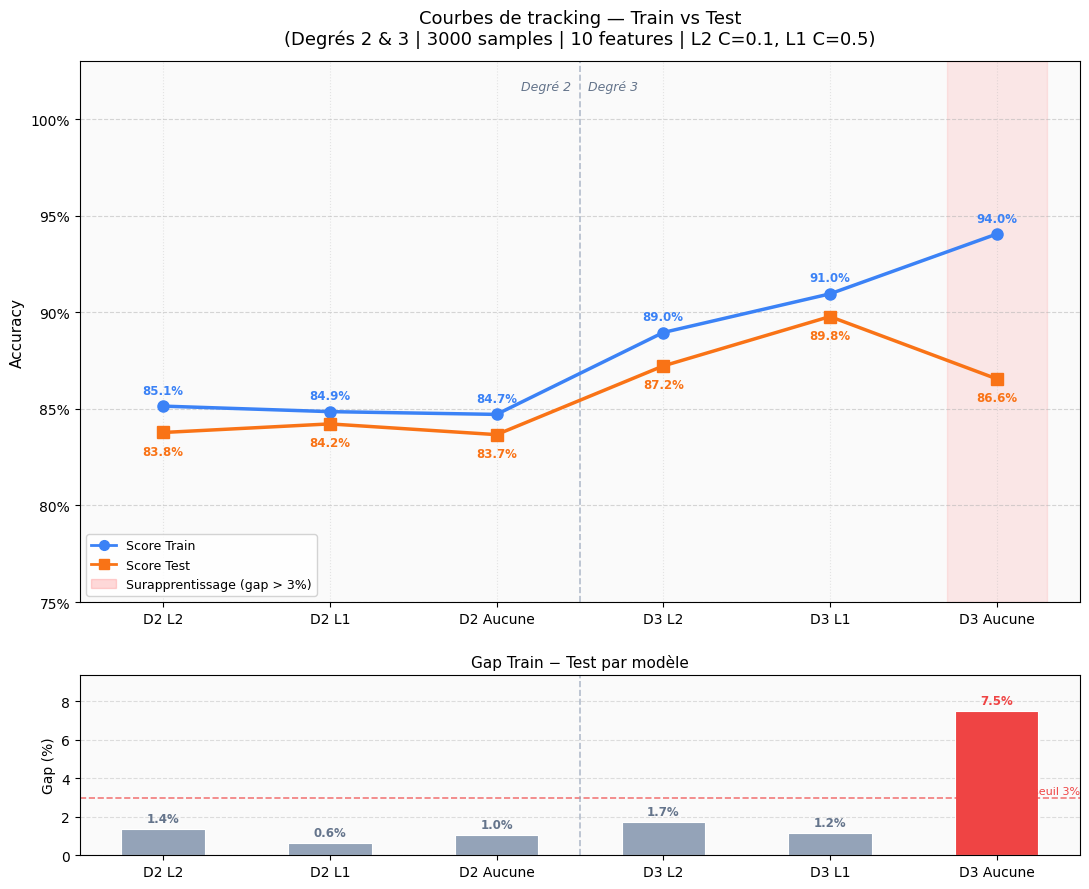


Graphique sauvegardé : train_test_tracking.png


In [15]:
# ── Modèles : Degrés 2 & 3, L1 (C=0.5) / L2 (C=0.1) / Aucune ──
degres = [2, 3]
modeles = {}
for d in degres:
    modeles[f'D{d} L2'] = make_pipeline(
        PolynomialFeatures(degree=d),
        StandardScaler(),
        LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', max_iter=2000)
    )
    modeles[f'D{d} L1'] = make_pipeline(
        PolynomialFeatures(degree=d),
        StandardScaler(),
        LogisticRegression(penalty='l1', C=0.5, solver='liblinear', max_iter=2000)
    )
    modeles[f'D{d} Aucune'] = make_pipeline(
        PolynomialFeatures(degree=d),
        StandardScaler(),
        LogisticRegression(penalty=None, max_iter=2000)
    )

# ── Entraînement & tracking des scores ──
noms, scores_train, scores_test = [], [], []
print('Entraînement en cours...')
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    s_tr = modele.score(X_train, y_train)
    s_te = modele.score(X_test,  y_test)
    noms.append(nom)
    scores_train.append(s_tr)
    scores_test.append(s_te)
    gap = s_tr - s_te
    flag = ' ⚠ surapprentissage' if gap > 0.03 else ''
    print(f'{nom:12s} | Train: {s_tr:.3f} | Test: {s_te:.3f} | Gap: {gap:.3f}{flag}')

# ── Courbes de tracking Train vs Test ──
x = np.arange(len(noms))
gaps = [t - e for t, e in zip(scores_train, scores_test)]

BLUE   = '#3b82f6'
ORANGE = '#f97316'

fig, axes = plt.subplots(2, 1, figsize=(11, 9),
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#ffffff')

ax = axes[0]
ax.set_facecolor('#fafafa')
for i, gap in enumerate(gaps):
    if gap > 0.03:
        ax.axvspan(i - 0.3, i + 0.3, color='red', alpha=0.08, zorder=0)

ax.plot(x, scores_train, color=BLUE,   marker='o', markersize=8, linewidth=2.5, label='Score Train', zorder=3)
ax.plot(x, scores_test,  color=ORANGE, marker='s', markersize=8, linewidth=2.5, label='Score Test',  zorder=3)

for i in range(len(noms)):
    ax.annotate(f'{scores_train[i]*100:.1f}%', (x[i], scores_train[i]),
                textcoords='offset points', xytext=(0, 9), ha='center', fontsize=8.5, color=BLUE, fontweight='bold')
    ax.annotate(f'{scores_test[i]*100:.1f}%', (x[i], scores_test[i]),
                textcoords='offset points', xytext=(0, -16), ha='center', fontsize=8.5, color=ORANGE, fontweight='bold')

mid = (len(noms) // 2) - 0.5
ax.axvline(mid, color='#94a3b8', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(mid - 0.05, 1.015, 'Degré 2', ha='right', fontsize=9, color='#64748b', fontstyle='italic')
ax.text(mid + 0.05, 1.015, 'Degré 3', ha='left',  fontsize=9, color='#64748b', fontstyle='italic')

ax.set_xlim(-0.5, len(noms) - 0.5)
ax.set_ylim(0.75, 1.03)
ax.set_xticks(x)
ax.set_xticklabels(noms, fontsize=10)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Courbes de tracking — Train vs Test\n'
             '(Degrés 2 & 3 | 3000 samples | 10 features | L2 C=0.1, L1 C=0.5)',
             fontsize=13, pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', linestyle=':', alpha=0.3)

patch_zone = mpatches.Patch(color='red', alpha=0.15, label='Surapprentissage (gap > 3%)')
ax.legend(handles=[
    plt.Line2D([0], [0], color=BLUE,   marker='o', linewidth=2, markersize=7, label='Score Train'),
    plt.Line2D([0], [0], color=ORANGE, marker='s', linewidth=2, markersize=7, label='Score Test'),
    patch_zone
], fontsize=9, loc='lower left', framealpha=0.85)

ax2 = axes[1]
ax2.set_facecolor('#fafafa')
colors_gap = ['#ef4444' if g > 0.03 else '#94a3b8' for g in gaps]
bars = ax2.bar(x, [g * 100 for g in gaps], color=colors_gap,
               width=0.5, zorder=2, edgecolor='white', linewidth=0.8)
ax2.axhline(3, color='#ef4444', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.text(len(noms) - 0.5, 3.2, 'seuil 3%', ha='right', fontsize=8, color='#ef4444')

for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{g*100:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold',
             color='#ef4444' if g > 0.03 else '#64748b')

ax2.set_xlim(-0.5, len(noms) - 0.5)
ax2.set_ylim(0, max(g * 100 for g in gaps) * 1.25)
ax2.set_xticks(x)
ax2.set_xticklabels(noms, fontsize=10)
ax2.set_ylabel('Gap (%)', fontsize=10)
ax2.set_title('Gap Train − Test par modèle', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.axvline(mid, color='#94a3b8', linewidth=1.2, linestyle='--', alpha=0.7)

plt.tight_layout(h_pad=2)
plt.savefig('train_test_tracking.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGraphique sauvegardé : train_test_tracking.png')


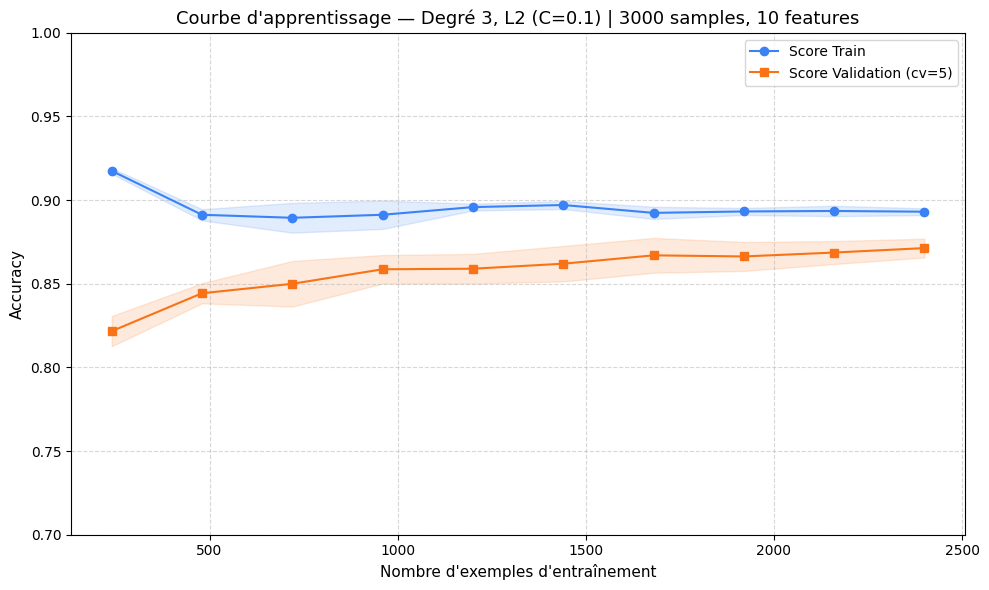

In [16]:
# ── Courbe d'apprentissage — Degré 3, L2 (C=0.1) ──
from sklearn.model_selection import learning_curve

model_final = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', max_iter=2000)
)

train_sizes, train_scores, test_scores = learning_curve(
    model_final, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean  = np.mean(test_scores,  axis=1)
train_std  = np.std(train_scores,  axis=1)
test_std   = np.std(test_scores,   axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#3b82f6', label='Score Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3b82f6')
plt.plot(train_sizes, test_mean, 's-', color='#f97316', label='Score Validation (cv=5)')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#f97316')

plt.title("Courbe d'apprentissage — Degré 3, L2 (C=0.1) | 3000 samples, 10 features", fontsize=13)
plt.xlabel("Nombre d'exemples d'entraînement", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()
